# PL diffusion simulation
This code simulate the PL imaging data in the presence of population decay and diffusion


## Import

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from hytools import (
    hy_basic as hyb,
)
from scipy.integrate import solve_ivp
from tqdm import tqdm as tqdm

## Define

In [37]:
def area_gaussian(x, sigma, A, x0):
    return A * 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - x0)**2 / (2 * sigma**2))

## Setup

In [38]:
# environment
L_MAX = 1               # total length of simulation
NX = 256            # number of pixels
DX = L_MAX / (NX - 1)
T_MAX = 100              # total time of simulation in ns
NT = 10000 # number of time steps
DT = T_MAX / (NT - 1)

x = np.linspace(-L_MAX, L_MAX, NX)  # grid, centered at x=0
t = np.linspace(0, T_MAX, NT)  # time grid

# photophysical
N0_TOTAL = 2.5E5    # Integrated n0 concentration unit in 1/um2. 
N0_SIGMA = 0.12      # width of Gaussian bump unit in um
D = 0e-5            # diffusion constant unit in cm2/s  
D = D/10            # convert to um2/ns
K1= 0.03
K2 = 1e-7
K3 = 0              # rate constant of k1, k2 and k3 in 1/ns, um2/ns and um4/ns
K_PL_ORDER = 1           # scaling order of photophysical constants. 1 for STE/exciton emission, 2 for bimodal emission.
# since we only care about relative intensity, the absolute value of PL rate is insignificant.

# setup initial population
N0 = area_gaussian(x, N0_SIGMA, N0_TOTAL, 0)  # initial population distribution
MAX_N = np.max(N0)  # maximum population. This will be set to ceil in the simulation


## TRPL simulation
This is for getting an idea of the overall TRPL without diffusion

Average population: 124511.71875000003
spatially average TRPL done! 1/e time: [26.50265027] ns


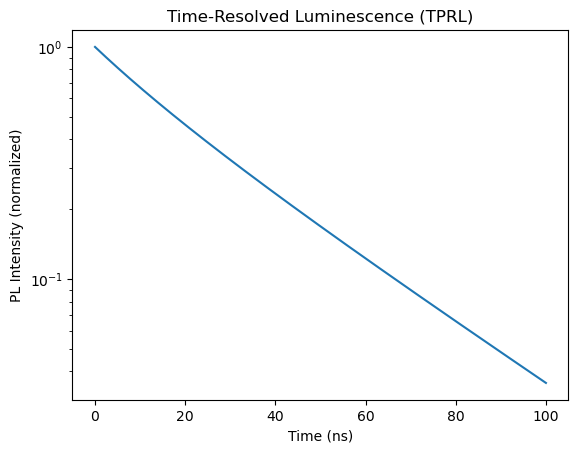

In [39]:
def x_avg_ode(t, y):
    n = y[0]   # extract scalar
    dn_dt = -n * K1 - n**2 * K2 - n**3 * K3
    return [dn_dt]


# get average population. This will be used to simulate spatially-averaged PL intensity.
xavg_n0 = np.mean(N0)
print(f"Average population: {xavg_n0}")
# solve ODE to get TPRL
trpl_sol = solve_ivp(fun=x_avg_ode,
          t_span = (t[0], t[-1]),
          y0 = [xavg_n0],
          t_eval = t,
          method = 'RK45',
          rtol = 1e-8,
          atol = 1e-8,
)
xavg_n = trpl_sol.y.T
xavg_trpl = xavg_n ** K_PL_ORDER
xavg_trpl = xavg_trpl / np.max(xavg_trpl)   # normalize
xavg_trpl_1e_time = t[hyb.numpy_nearest(xavg_trpl, 1/np.e, 'idx')]

%matplotlib inline  
# plot
fig, ax = plt.subplots()
ax.semilogy(t, xavg_trpl, label='TPRL')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('PL Intensity (normalized)')
ax.set_title('Time-Resolved Luminescence (TPRL)')
print(f"spatially average TRPL done! 1/e time: {xavg_trpl_1e_time} ns")


## diffusion

In [40]:
# test stability condition
if D > 0:
    dif_dt_max = DX**2 / (2 * D)
    print(f"Maximum allowed DT for stability: {dif_dt_max:.2e}")
    if DT > dif_dt_max:
        print(f"Warning: DT ({DT:.2e}) is larger than the maximum allowed value ({dif_dt_max:.2e}) for stability.")
data = np.zeros((NT, NX))
data[0, :] = N0  # initial population distribution

# time_stepping
for i in tqdm(range(1, NT)):
    d2N_dx2 = (np.roll(data[i-1, :], -1) - 2*data[i-1, :] + np.roll(data[i-1, :], 1)) / DX**2
    # Neumann BC (zero gradient): copy edges
    d2N_dx2[0]  = d2N_dx2[1]
    d2N_dx2[-1] = d2N_dx2[-2]

    data[i, :] = data[i-1, :] + DT * (D * d2N_dx2 - K1 * data[i-1, :] - K2 * data[i-1, :]**2 - K3 * data[i-1, :]**3)
    data[i, :] = np.clip(data[i, :], 0, MAX_N)  # or whatever max is physically reasonable

# normalize to spatial for ease of plotting
data_normt = data / np.max(data, axis=1)[:, None]

PL_result = data ** K_PL_ORDER
PL_result_normt = PL_result / np.max(PL_result, axis=1)[:, None]

100%|██████████| 9999/9999 [00:00<00:00, 22788.60it/s]


## plot


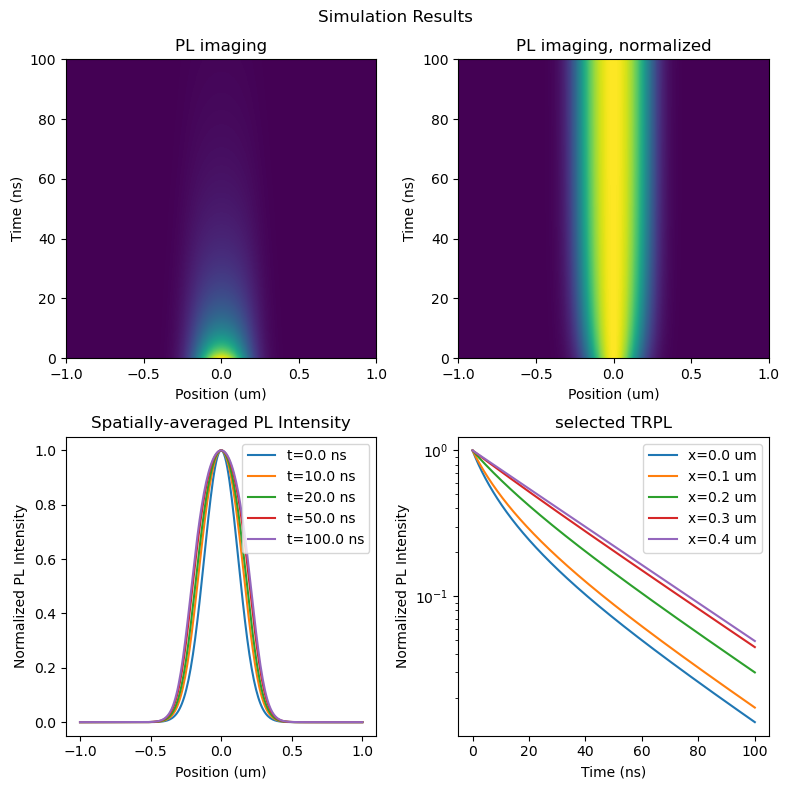

In [41]:
key_frames = np.array([0, 0.1, 0.2, 0.5, 1])
key_frames = T_MAX * key_frames

key_x = np.array([0, 0.1, 0.2, 0.3, 0.4])
key_x = L_MAX * key_x

fig, axes = plt.subplots(2,2, figsize = (8,8))
axes = axes.flatten()
fig.suptitle('Simulation Results')

axes[0].set_title('PL imaging')
axes[0].imshow(PL_result, aspect='auto', extent=[x[0], x[-1], t[0], t[-1]], origin = 'lower')
axes[0].set_xlabel('Position (um)')
axes[0].set_ylabel('Time (ns)')
axes[0].set_aspect('auto')

axes[1].set_title('PL imaging, normalized')
axes[1].imshow(PL_result_normt, aspect='auto', extent=[x[0], x[-1], t[0], t[-1]], origin = 'lower')
axes[1].set_xlabel('Position (um)')
axes[1].set_ylabel('Time (ns)')
axes[1].set_aspect('auto')

axes[2].set_title('Spatially-averaged PL Intensity')
for j in range(len(key_frames)):
    axes[2].plot(x, PL_result_normt[int(hyb.numpy_nearest(t, key_frames[j], 'idx')), :], label=f't={key_frames[j]:.1f} ns')
axes[2].set_xlabel('Position (um)')
axes[2].set_ylabel('Normalized PL Intensity')
axes[2].legend()

axes[3].set_title('selected TRPL')
for j in range(len(key_x)):
    temp_pl_norm = PL_result[:, int(hyb.numpy_nearest(x, key_x[j], 'idx'))] / np.max(PL_result[:, int(hyb.numpy_nearest(x, key_x[j], 'idx'))])
    axes[3].semilogy(t, temp_pl_norm, label=f'x={key_x[j]:.1f} um')
axes[3].set_xlabel('Time (ns)')
axes[3].set_ylabel('Normalized PL Intensity')
axes[3].legend()

plt.tight_layout()

In [42]:
# test

print("Job done!")

Job done!
